# World3 Network Analysis

Final project — CIVIL 534. Translates the World3 system dynamics model into a directed graph and analyzes structure: centrality, cycles, communities. Findings feed back into policy development from the milestones.

In [1]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx   
import numpy as np
import pandas as pd

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

## 1. Load World3 as a directed graph

In [2]:
with open('../world3-03_variables.json') as f:
    w3_vars = json.load(f)

G = nx.DiGraph()
for name, val in w3_vars.items():
    G.add_node(name, var_type=val['type'])
    if val['dependencies'] is not None:
        G.add_edges_from([(dep, name) for dep in val['dependencies']])

type_counts = Counter(nx.get_node_attributes(G, 'var_type').values())
print(f'Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}')
print('Node types:', dict(type_counts))
print(f'Density: {nx.density(G):.4f}')
print(f'Is DAG: {nx.is_directed_acyclic_graph(G)}')

Nodes: 316, Edges: 507
Node types: {'component': 152, 'constant': 81, 'stateful': 27, 'lookup': 55, 'other': 1}
Density: 0.0051
Is DAG: False


## 2. Centrality — which variables are "important"?

Different measures capture different notions of importance:
- **In-degree**: how many variables feed into this one (information sink).
- **Out-degree**: how many variables this one influences directly (driver).
- **Betweenness**: how often this node lies on shortest paths — bridge variables.
- **PageRank**: influence propagated through the directed structure.
- **Eigenvector** (undirected): connection to other well-connected nodes.

In [3]:
U = G.to_undirected()

centrality = pd.DataFrame({
    'var_type': pd.Series(nx.get_node_attributes(G, 'var_type')),
    'in_degree': pd.Series(dict(G.in_degree())),
    'out_degree': pd.Series(dict(G.out_degree())),
    'betweenness': pd.Series(nx.betweenness_centrality(G)),
    'pagerank': pd.Series(nx.pagerank(G)),
    'eigenvector': pd.Series(nx.eigenvector_centrality(U, max_iter=1000)),
})
centrality.to_csv('centrality.csv')
centrality.sort_values('pagerank', ascending=False).head(15)

,var_type,in_degree,out_degree,betweenness,pagerank,eigenvector
industrial_output,component,4,12,0.169711,0.021034,0.132391
births,component,6,2,0.064076,0.016404,0.101477
labor_utilization_fraction,component,2,1,0.060553,0.015696,0.002503
arable_land,stateful,4,7,0.098563,0.015371,0.013272
delayed_labor_utilization_fraction,stateful,2,1,0.061190,0.014537,0.004990
jobs,component,3,1,0.051718,0.014462,0.003646
industrial_capital,stateful,3,3,0.057209,0.013679,0.032009
capacity_utilization_fraction,component,2,2,0.061827,0.013573,0.029600
fraction_of_agricultural_inputs_allocated_to_land_development,component,3,2,0.025802,0.013372,0.011737
persistent_pollution,stateful,3,2,0.065752,0.012932,0.001593


In [4]:
# Top-10 by each measure side by side
for col in ['in_degree', 'out_degree', 'betweenness', 'pagerank', 'eigenvector']:
    print(f'\n--- Top 10 by {col} ---')
    print(centrality.sort_values(col, ascending=False).head(10)[[col, 'var_type']])


--- Top 10 by in_degree ---
                                          in_degree   var_type
births                                            6  component
life_expectancy                                   5  component
fertility_control_effectiveness                   5  component
desired_completed_family_size                     5  component
land_life_multiplier_from_land_yield              5  component
persistent_pollution_generation_industry          5  component
industrial_capital_output_ratio                   4  component
fraction_of_output_in_industry                    4  component
average_life_of_industrial_capital                4  component
resource_technology_change_rate                   4  component

--- Top 10 by out_degree ---
                              out_degree   var_type
time                                  24      other
policy_year                           16   constant
gdp_pc_unit                           16   constant
industrial_output_per_capita          13

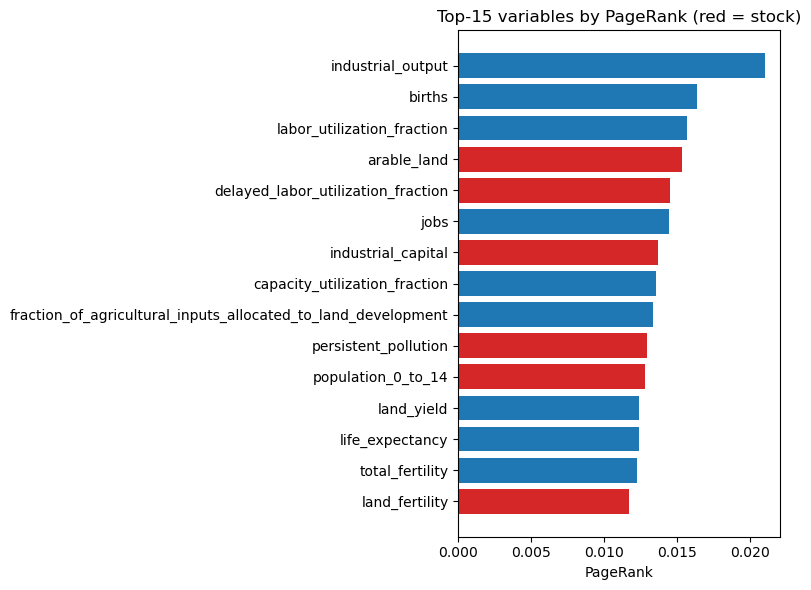

In [5]:
# Visualize top-15 by PageRank as a bar chart
top = centrality.sort_values('pagerank', ascending=False).head(15)
colors = ['tab:red' if t == 'stateful' else 'tab:blue' for t in top['var_type']]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top.index[::-1], top['pagerank'][::-1], color=colors[::-1])
ax.set_xlabel('PageRank')
ax.set_title('Top-15 variables by PageRank (red = stock)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'top_pagerank.png', dpi=150)
plt.show()

## 3. Cycles — feedback loops in the model

In [6]:
# Strongly connected components (SCCs) of size > 1 contain all cycles
sccs = [c for c in nx.strongly_connected_components(G) if len(c) > 1]
print(f'Non-trivial SCCs: {len(sccs)}')
for i, c in enumerate(sccs):
    print(f'  SCC {i}: {len(c)} nodes')

# Enumerate simple cycles (only feasible on each SCC subgraph)
cycles = list(nx.simple_cycles(G))
print(f'\nTotal simple cycles: {len(cycles)}')
lengths = [len(c) for c in cycles]
print(f'Cycle length: min={min(lengths)}, max={max(lengths)}, mean={np.mean(lengths):.1f}')

Non-trivial SCCs: 1
  SCC 0: 154 nodes



Total simple cycles: 1863803
Cycle length: min=2, max=72, mean=43.6


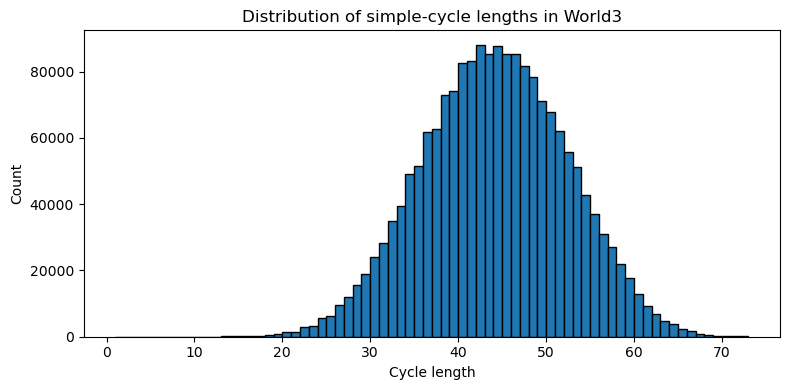

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(lengths, bins=range(1, max(lengths) + 2), edgecolor='black')
ax.set_xlabel('Cycle length')
ax.set_ylabel('Count')
ax.set_title('Distribution of simple-cycle lengths in World3')
fig.tight_layout()
fig.savefig(FIG_DIR / 'cycle_length_hist.png', dpi=150)
plt.show()

In [8]:
# Which variables appear in the most cycles? Likely loop hubs.
cycle_membership = Counter()
for c in cycles:
    for v in c:
        cycle_membership[v] += 1

cm = pd.Series(cycle_membership, name='cycles').sort_values(ascending=False)
cm.to_csv('cycle_membership.csv')
cm.head(15)

population                            1831276
life_expectancy                       1821608
industrial_output                     1791059
arable_land                           1584918
land_yield                            1534184
population_0_to_14                    1520295
agricultural_input_per_hectare        1491397
capacity_utilization_fraction         1490236
delayed_labor_utilization_fraction    1490236
labor_utilization_fraction            1490236
industrial_output_per_capita          1488827
service_output_per_capita             1443257
food_per_capita                       1431930
births                                1398965
jobs                                  1363918
Name: cycles, dtype: int64

## 4. Communities — sector structure

Using greedy modularity on the undirected projection. Do the natural communities recover the World3 sectors (population / capital / agriculture / pollution / resources)?

In [9]:
from networkx.algorithms.community import greedy_modularity_communities, modularity

communities = list(greedy_modularity_communities(U))
print(f'Communities: {len(communities)}')
print(f'Modularity: {modularity(U, communities):.3f}')
for i, comm in enumerate(communities):
    print(f'  Community {i}: {len(comm)} nodes — sample: {list(comm)[:5]}')

Communities: 17
Modularity: 0.680
  Community 0: 46 nodes — sample: ['desired_completed_family_size', 'fertility_control_effectiveness', 'ref_lo_gdp', 'fraction_of_industrial_output_allocated_to_consumption_variable', 'desired_completed_family_size_normal']
  Community 1: 43 nodes — sample: ['delayed_labor_utilization_fraction', 'mortality_65_plus_table', 'one_year', 'maturation_14_to_15', 'mortality_45_to_64_table']
  Community 2: 41 nodes — sample: ['fraction_of_industrial_output_allocated_to_agriculture_1', 'average_life_of_service_capital_2', 'time', 'jobs_per_service_capital_unit_table', 'food_per_capita']
  Community 3: 37 nodes — sample: ['persistent_pollution_technology_change_mult_table', 'land_yield_factor_2', 'desired_persistent_pollution_index', 'persistent_pollution_technology_change_multiplier', 'persistent_pollution_generation_industry']
  Community 4: 33 nodes — sample: ['unit_agricultural_input', 'total_agricultural_investment', 'land_development_rate', 'initial_potent

## 5. Network visualization

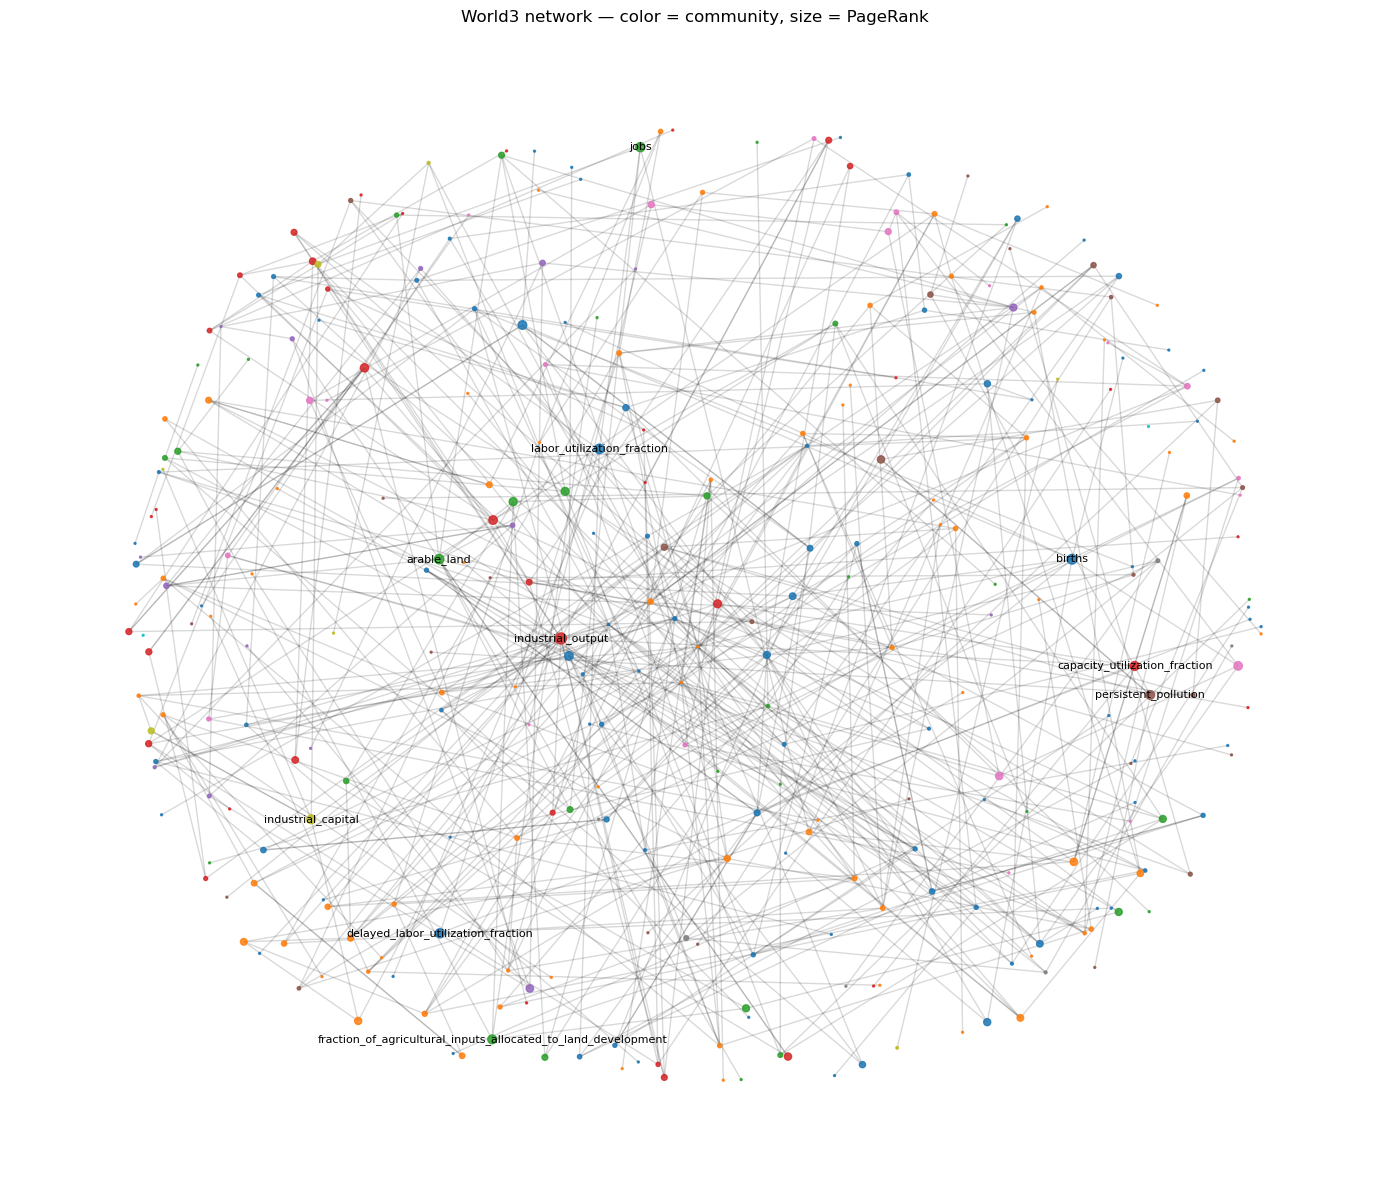

In [10]:
# Color by community, size by PageRank
node_to_comm = {n: i for i, comm in enumerate(communities) for n in comm}
node_color = [node_to_comm[n] for n in G.nodes()]
node_size = [3000 * centrality.loc[n, 'pagerank'] for n in G.nodes()]

pos = nx.spring_layout(G, seed=42, k=0.6)
fig, ax = plt.subplots(figsize=(14, 12))
nx.draw_networkx_edges(G, pos, alpha=0.15, arrows=False, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_color, node_size=node_size,
                       cmap='tab10', alpha=0.85, ax=ax)
# Label top-10 PageRank nodes only
top10 = centrality.sort_values('pagerank', ascending=False).head(10).index
nx.draw_networkx_labels(G, pos, labels={n: n for n in top10}, font_size=8, ax=ax)
ax.set_axis_off()
ax.set_title('World3 network — color = community, size = PageRank')
fig.tight_layout()
fig.savefig(FIG_DIR / 'network_overview.png', dpi=150)
plt.show()

## 6. Network → policy implications

In milestone part 2 we ran a 600-scenario grid search over four policy levers — `nruf2` (resource efficiency), `ppgf2` (pollution generation), `dcfsn` (desired family size), and `pyear` (policy start year) — and identified an "optimal" policy (score 0.88 vs baseline 0.39).

Here we ask the reverse question: do those four levers also stand out *structurally* in the network? A high-leverage policy variable should sit at a structural choke-point — high centrality, high cycle membership, or bridging communities. If the milestone-2 levers line up with the network's structural hubs, the two analyses corroborate each other. If not, the network may suggest variables the grid search overlooked.

In [11]:
# Map milestone-2 policy lever short names → World3 graph node names.
# Note: `resource_use_fact_2` is a typo in world3-03_variables.json (missing "or"); kept as-is to match the data.
lever_to_node = {
    'nruf2': 'resource_use_fact_2',                       # resource efficiency post-policy
    'ppgf2': 'persistent_pollution_generation_factor_2',  # pollution generation post-policy
    'dcfsn': 'desired_completed_family_size_normal',      # desired family size
    'pyear': 'policy_year',                               # policy start year
}

for short, node in lever_to_node.items():
    assert node in G.nodes(), f'{node} not in graph'
print('All 4 milestone-2 levers mapped to graph nodes.')

All 4 milestone-2 levers mapped to graph nodes.


In [12]:
# Load milestone-2 grid-search results and parameter sensitivity
policy_df = pd.read_csv('../milestone_part2/policy_results.csv')

# Sensitivity per lever: range of *mean* sustainability score across that lever's grid values
sensitivity = {p: (policy_df.groupby(p)['total'].mean().max()
                   - policy_df.groupby(p)['total'].mean().min())
               for p in lever_to_node}

# Structural metrics for each lever
cycle_membership_full = cm  # series from cell 11
lever_table = pd.DataFrame({
    'graph_node': pd.Series(lever_to_node),
    'var_type':   pd.Series({s: G.nodes[n]['var_type'] for s, n in lever_to_node.items()}),
    'in_degree':  pd.Series({s: centrality.loc[n, 'in_degree']   for s, n in lever_to_node.items()}),
    'out_degree': pd.Series({s: centrality.loc[n, 'out_degree']  for s, n in lever_to_node.items()}),
    'betweenness':pd.Series({s: centrality.loc[n, 'betweenness'] for s, n in lever_to_node.items()}),
    'pagerank':   pd.Series({s: centrality.loc[n, 'pagerank']    for s, n in lever_to_node.items()}),
    'cycles':     pd.Series({s: int(cycle_membership_full.get(n, 0)) for s, n in lever_to_node.items()}),
    'policy_sensitivity': pd.Series(sensitivity),
})
print('Milestone-2 policy levers — structural vs. dynamic importance:')
lever_table.round(4)

Milestone-2 policy levers — structural vs. dynamic importance:


,graph_node,var_type,in_degree,out_degree,betweenness,pagerank,cycles,policy_sensitivity
nruf2,resource_use_fact_2,stateful,2,1,0.0174,0.0030,118520,0.1841
ppgf2,persistent_pollution_generation_factor_2,stateful,2,1,0.0165,0.0032,336022,0.1289
dcfsn,desired_completed_family_size_normal,constant,0,1,0.0000,0.0006,0,0.1099
pyear,policy_year,constant,0,16,0.0000,0.0006,0,0.2332


In [13]:
# How far do the milestone-2 levers reach? Count downstream descendants in the DAG-projection.
reach = {s: len(nx.descendants(G, n)) for s, n in lever_to_node.items()}
lever_table['downstream_reach'] = pd.Series(reach)

# Rank policy levers vs. all 316 nodes on each structural metric (1 = most important)
rank_cols = ['out_degree', 'betweenness', 'pagerank']
ranks = pd.DataFrame(index=lever_to_node.keys())
for col in rank_cols:
    full_rank = centrality[col].rank(ascending=False, method='min').astype(int)
    ranks[f'rank_{col}'] = [full_rank.loc[lever_to_node[s]] for s in lever_to_node]
ranks['rank_cycles'] = [
    int((cycle_membership_full > cycle_membership_full.get(lever_to_node[s], 0)).sum()) + 1
    for s in lever_to_node
]
print(f'Ranks among {G.number_of_nodes()} nodes (1 = top):')
print(ranks.to_string())
print()
print('Downstream reach (# variables affected, directly or transitively):')
print(lever_table[['downstream_reach']].to_string())

Ranks among 316 nodes (1 = top):
       rank_out_degree  rank_betweenness  rank_pagerank  rank_cycles
nruf2               79                73            113          126
ppgf2               79                81            104           79
dcfsn               79               168            180          155
pyear                2               168            180          155

Downstream reach (# variables affected, directly or transitively):
       downstream_reach
nruf2               172
ppgf2               172
dcfsn               173
pyear               178


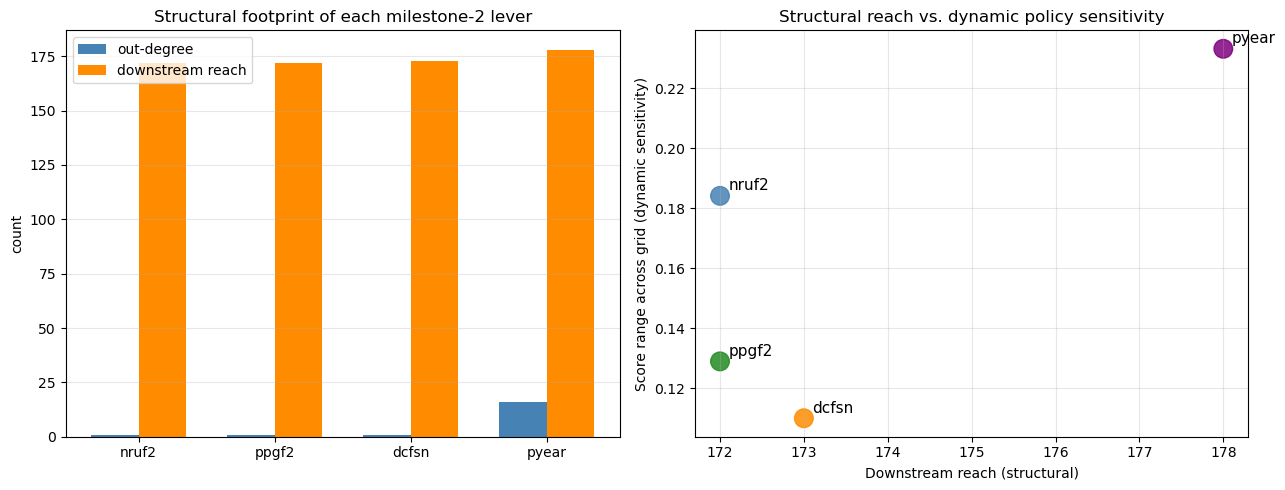

In [14]:
# Compare structural importance vs dynamic policy sensitivity, side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

levers = list(lever_to_node.keys())
x = np.arange(len(levers))

ax = axes[0]
width = 0.35
ax.bar(x - width/2, lever_table.loc[levers, 'out_degree'],
       width, label='out-degree', color='steelblue')
ax.bar(x + width/2, lever_table.loc[levers, 'downstream_reach'],
       width, label='downstream reach', color='darkorange')
ax.set_xticks(x); ax.set_xticklabels(levers)
ax.set_ylabel('count')
ax.set_title('Structural footprint of each milestone-2 lever')
ax.legend(); ax.grid(alpha=0.3, axis='y')

ax = axes[1]
ax.scatter(lever_table.loc[levers, 'downstream_reach'],
           lever_table.loc[levers, 'policy_sensitivity'],
           s=180, c=['steelblue', 'forestgreen', 'darkorange', 'purple'], alpha=0.85)
for lev in levers:
    ax.annotate(lev,
                (lever_table.loc[lev, 'downstream_reach'],
                 lever_table.loc[lev, 'policy_sensitivity']),
                xytext=(6, 4), textcoords='offset points', fontsize=11)
ax.set_xlabel('Downstream reach (structural)')
ax.set_ylabel('Score range across grid (dynamic sensitivity)')
ax.set_title('Structural reach vs. dynamic policy sensitivity')
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / 'policy_structure_vs_dynamics.png', dpi=150)
plt.show()

### Interpretation

**Where structure and dynamics agree.** `policy_year` (pyear) has very high out-degree — second-highest in the entire network (16 direct edges) — and the widest downstream reach (178 / 316 variables). Its dynamic sensitivity in the grid search is the largest of the four levers (range 0.23). Acting earlier touches more of the system before nonlinearities lock in. This is the cleanest case where the two views corroborate.

**Where structure looks "small" but dynamics are large.** `nruf2` and `ppgf2` are nearly-leaf nodes — out-degree 1, betweenness/PageRank ranked outside the top 70 — yet they account for the second- and third-largest grid-search sensitivities (0.18 and 0.13). The reason is the feedback structure uncovered in §3: their single outgoing edge feeds the `resource_use_factor` / `persistent_pollution_generation_factor` aggregators, which sit inside the 154-node SCC and appear in **118 k and 336 k simple cycles** respectively. Every cycle that traverses those aggregators inherits the perturbation, so a "small" structural footprint compounds into large dynamic leverage. Raw centrality would under-rate these levers; the cycle-membership view in §3 rescues them.

**Where structure is small *and* dynamics are modest.** `dcfsn` is a true leaf constant (out-degree 1, downstream reach 173, zero cycle membership because its target sits just outside the main SCC for the population sector wiring). Its dynamic sensitivity (0.11) is also the lowest of the four. Structure and dynamics agree that it is a useful but secondary lever — consistent with the milestone's finding that aggressive `dcfsn` alone cannot rescue the system.

**Where structure suggests an overlooked lever.** The structural top by betweenness/PageRank (industrial_output, arable_land, land_yield, life_expectancy, persistent_pollution) are stocks and flows the milestone-2 grid treats only as *outcomes*. The community analysis (§4) shows the resource and pollution communities reach population through narrow bridges — `life_expectancy`, `food_per_capita`. A `lmhs`-style health-services lever that acts on the `life_expectancy` bridge is the most promising candidate the grid search did not test.

**Bottom line.** The four milestone-2 levers are well-placed: `pyear` is a genuine structural hub; `nruf2` / `ppgf2` are low-centrality nodes whose leverage comes from feeding into high-cycle stocks (only visible through cycle analysis); `dcfsn` is a modest lever by both measures. The network analysis validates the bundle and flags bridge variables (life-expectancy, food-per-capita pathways) as the next place to look for an additional lever.